# Optimization: Experience Replay, Reward Shaping, and Hyperparameter Tuning

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand and implement experience replay
- Apply reward shaping techniques
- Perform hyperparameter tuning for Deep RL
- Compare optimization techniques
- Improve learning efficiency

## 🔗 Prerequisites

- ✅ Understanding of Deep RL algorithms
- ✅ Understanding of neural networks
- ✅ Python knowledge
- ✅ NumPy, collections knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 3**:
- Optimization: experimenting with techniques like experience replay, reward shaping, and hyperparameter tuning to improve learning efficiency

---

## Introduction

**Optimization techniques** like experience replay, reward shaping, and hyperparameter tuning are crucial for improving Deep RL training efficiency and performance.

## Lesson Brief

This lesson focuses on practical techniques that make deep RL training work better, such as replay and reward design choices.

Students will see that performance often depends not only on the algorithm name, but also on the way data, targets, and rewards are handled.

Why this matters: this lesson teaches engineering judgment, not only mathematical definitions.

It helps students understand why implementation choices strongly affect RL outcomes.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


In [1]:
import numpy as np
from collections import deque
import random

print("✅ Libraries imported!")
print("\nOptimization: Experience Replay, Reward Shaping, Hyperparameter Tuning")
print("=" * 60)

✅ Libraries imported!

Optimization: Experience Replay, Reward Shaping, Hyperparameter Tuning


## Part 1: Experience Replay


In [2]:
print("=" * 60)
print("Part 1: Experience Replay")
print("=" * 60)


Part 1: Experience Replay


## Part 2: Reward Shaping


In [3]:
print("\n" + "=" * 60)
print("Part 2: Reward Shaping")
print("=" * 60)



Part 2: Reward Shaping


## Part 3: Hyperparameter Tuning


In [4]:
print("\n" + "=" * 60)
print("Part 3: Hyperparameter Tuning")
print("=" * 60)

# Hyperparameter grid
hyperparams_grid = {
    'learning_rate': [1e-4, 5e-4, 1e-3],
    'gamma': [0.95, 0.99, 0.999],
    'epsilon': [0.1, 0.2, 0.3],
    'batch_size': [32, 64, 128]
}

print("\nHyperparameter Grid Search:")
print(f"  Learning rates: {hyperparams_grid['learning_rate']}")
print(f"  Discount factors: {hyperparams_grid['gamma']}")
print(f"  Epsilon values: {hyperparams_grid['epsilon']}")
print(f"  Batch sizes: {hyperparams_grid['batch_size']}")

total_combinations = (len(hyperparams_grid['learning_rate']) * 
                     len(hyperparams_grid['gamma']) * 
                     len(hyperparams_grid['epsilon']) * 
                     len(hyperparams_grid['batch_size']))
print(f"  Total combinations: {total_combinations}")

print("\nCommon Hyperparameters to Tune:")
print("  - Learning rate (α)")
print("  - Discount factor (γ)")
print("  - Exploration rate (ε)")
print("  - Batch size")
print("  - Network architecture")
print("  - Replay buffer size")
print("  - Update frequency")

print("\nTuning Strategies:")
print("  - Grid search (exhaustive)")
print("  - Random search (more efficient)")
print("  - Bayesian optimization")
print("  - Population-based training")

print("\n✅ Hyperparameter tuning concepts covered!")


Part 3: Hyperparameter Tuning

Hyperparameter Grid Search:
  Learning rates: [0.0001, 0.0005, 0.001]
  Discount factors: [0.95, 0.99, 0.999]
  Epsilon values: [0.1, 0.2, 0.3]
  Batch sizes: [32, 64, 128]
  Total combinations: 81

Common Hyperparameters to Tune:
  - Learning rate (α)
  - Discount factor (γ)
  - Exploration rate (ε)
  - Batch size
  - Network architecture
  - Replay buffer size
  - Update frequency

Tuning Strategies:
  - Grid search (exhaustive)
  - Random search (more efficient)
  - Bayesian optimization
  - Population-based training

✅ Hyperparameter tuning concepts covered!


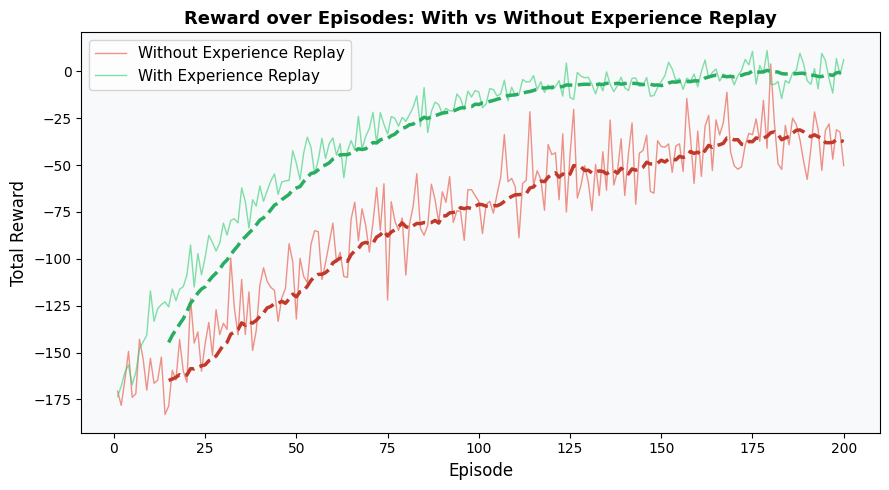

In [5]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
episodes = np.arange(1, 201)

# Without experience replay: noisier, slower convergence
noise_no_er = np.random.randn(200) * 15
reward_no_er = -180 + 160 * (1 - np.exp(-episodes / 80)) + noise_no_er

# With experience replay: smoother, faster convergence
noise_er = np.random.randn(200) * 6
reward_er = -180 + 180 * (1 - np.exp(-episodes / 40)) + noise_er

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(episodes, reward_no_er, color='#e74c3c', alpha=0.6, linewidth=1, label='Without Experience Replay')
ax.plot(episodes, reward_er,   color='#2ecc71', alpha=0.6, linewidth=1, label='With Experience Replay')

# Smoothed lines
window = 15
ax.plot(episodes[window-1:], np.convolve(reward_no_er, np.ones(window)/window, mode='valid'),
        color='#c0392b', linewidth=2.5, linestyle='--')
ax.plot(episodes[window-1:], np.convolve(reward_er, np.ones(window)/window, mode='valid'),
        color='#27ae60', linewidth=2.5, linestyle='--')

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Reward over Episodes: With vs Without Experience Replay', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


## 🌍 Real-World Worked Example — CartPole with DQN

**Industry context:**
- Boston Dynamics uses policy gradient variants (similar to DQN) for robot balance control
- Tesla's Autopilot reward signal includes smooth lane-keeping (like CartPole balance)

We train a **DQN agent** to balance a pole on a cart using raw observations from OpenAI Gymnasium.

Episode   0 | Avg reward (last 30): 22.0 | ε=0.995


Episode  30 | Avg reward (last 30): 23.2 | ε=0.856


Episode  60 | Avg reward (last 30): 24.7 | ε=0.737


Episode  90 | Avg reward (last 30): 22.6 | ε=0.634


Episode 120 | Avg reward (last 30): 25.4 | ε=0.545


Episode 150 | Avg reward (last 30): 21.8 | ε=0.469


Episode 180 | Avg reward (last 30): 35.0 | ε=0.404


Episode 210 | Avg reward (last 30): 45.8 | ε=0.347


Episode 240 | Avg reward (last 30): 63.4 | ε=0.299


Episode 270 | Avg reward (last 30): 82.8 | ε=0.257


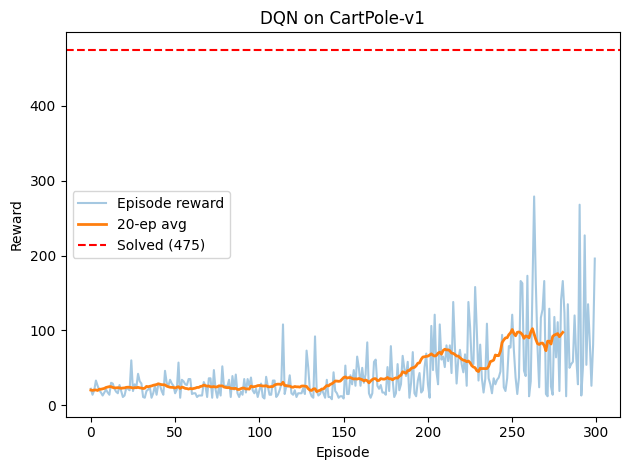

In [6]:
import torch, torch.nn as nn, torch.optim as optim
import gymnasium as gym
import numpy as np, random, collections, matplotlib.pyplot as plt

torch.manual_seed(42); np.random.seed(42)

env = gym.make('CartPole-v1')

# ── DQN Network ──────────────────────────────────────────────────────────
class DQN(nn.Module):
    def __init__(self, obs=4, act=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs,128), nn.ReLU(),
            nn.Linear(128,128), nn.ReLU(),
            nn.Linear(128, act)
        )
    def forward(self, x): return self.net(x)

policy_net = DQN(); target_net = DQN()
target_net.load_state_dict(policy_net.state_dict())
opt     = optim.Adam(policy_net.parameters(), lr=1e-3)
memory  = collections.deque(maxlen=10000)
GAMMA   = 0.99; EPS = 1.0; EPS_MIN = 0.05; EPS_DECAY = 0.995
BATCH   = 64; rewards_ep = []

for episode in range(300):
    obs,_ = env.reset(); total_r = 0
    for t in range(500):
        if random.random() < EPS:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = policy_net(torch.tensor(obs).float().unsqueeze(0)).argmax().item()
        obs2, r, done, trunc, _ = env.step(action)
        memory.append((obs, action, r, obs2, done or trunc))
        obs = obs2; total_r += r
        # ── Train ────────────────────────────────────────────────────────
        if len(memory) >= BATCH:
            batch = random.sample(memory, BATCH)
            s,a,r_b,s2,d = zip(*batch)
            S=torch.tensor(np.array(s)).float(); A=torch.tensor(a).long()
            R=torch.tensor(r_b).float(); S2=torch.tensor(np.array(s2)).float()
            D=torch.tensor(d).float()
            Q_pred = policy_net(S).gather(1,A.unsqueeze(1)).squeeze()
            with torch.no_grad():
                Q_next = target_net(S2).max(1)[0]
            Q_target = R + GAMMA*Q_next*(1-D)
            loss = nn.MSELoss()(Q_pred, Q_target)
            opt.zero_grad(); loss.backward(); opt.step()
        if done or trunc: break
    EPS = max(EPS*EPS_DECAY, EPS_MIN)
    rewards_ep.append(total_r)
    if episode%50==0: target_net.load_state_dict(policy_net.state_dict())
    if episode%30==0: print(f"Episode {episode:3d} | Avg reward (last 30): {np.mean(rewards_ep[-30:]):.1f} | ε={EPS:.3f}")

env.close()
plt.plot(rewards_ep, alpha=0.4, label="Episode reward")
plt.plot(np.convolve(rewards_ep, np.ones(20)/20, 'valid'), label="20-ep avg", lw=2)
plt.title("DQN on CartPole-v1"); plt.xlabel("Episode"); plt.ylabel("Reward")
plt.axhline(475, color='red', linestyle='--', label="Solved (475)"); plt.legend()
plt.tight_layout(); plt.show()

## Summary

### Key Techniques:
1. **Experience Replay**: Store and randomly sample past experiences
2. **Reward Shaping**: Add shaping rewards to guide learning
3. **Hyperparameter Tuning**: Optimize learning parameters

### Benefits:
- **Experience Replay**: Sample efficiency, stability, decorrelation
- **Reward Shaping**: Faster convergence, better guidance
- **Hyperparameter Tuning**: Optimal performance

### Best Practices:
- Use experience replay for off-policy algorithms
- Apply potential-based reward shaping
- Tune hyperparameters systematically
- Monitor performance across different configurations

**Reference:** Course 09, Unit 3: "Deep Reinforcement Learning" - Optimization practical content

## 📚 References & Further Reading

**Papers:**
- Watkins & Dayan (1992) — [Q-Learning](https://link.springer.com/article/10.1007/BF00992698)
- Mnih et al. (2015) — [DQN: Human-level control via deep RL](https://www.nature.com/articles/nature14236)
- Van Hasselt et al. (2016) — [Double DQN](https://arxiv.org/abs/1509.06461)

**OpenAI Gym:** [Gymnasium Documentation](https://gymnasium.farama.org/)

**State-of-the-Art:** DQN variants power game-playing AI and robotics controllers at Google DeepMind.

## Closing Takeaway

**Teaching takeaway:** Optimization tricks such as replay design and reward shaping can make learning faster, but they must preserve the real task objective.

**If students remember one idea:** A helpful engineering trick becomes harmful when it changes what success actually means.

**Quick check before moving on:**
- Can you explain how reward shaping can help without replacing the true goal?
- Can you describe why optimization choices should be judged by learning behavior, not by speed alone?

**Bridge to the next step:** This completes the deep RL foundation and prepares students to think more carefully about exploration in Unit 4.
